In [4]:
import pandas as pd

df = pd.read_csv("../data/OnlineRetail.csv", encoding="ISO-8859-1")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.shape

(1067371, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [9]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [10]:
# Negative quantity = returned products.

In [11]:
df.duplicated().sum()

np.int64(34335)

In [12]:
df.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

In [13]:
df[df['Invoice']=='C489449']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


<p style="color:blue;font-size:20px;">
 Here Invoices starting with "C" represent cancelled transactions. Since they reflect reversed or invalid sales, including them would distort revenue and demand analysis. Therefore, they were removed for clean predictive modeling.
</p>

In [14]:
df[df['Invoice'].astype(str).str.startswith('C')].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [15]:
df[df['Invoice'].astype(str).str.startswith('C')].iloc[0]

Invoice                         C489449
StockCode                         22087
Description    PAPER BUNTING WHITE LACE
Quantity                            -12
InvoiceDate         2009-12-01 10:33:00
Price                              2.95
Customer ID                     16321.0
Country                       Australia
Name: 178, dtype: object

In [16]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [17]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


<p style="color:blue;font-size:20px;">
     Negative quantities correspond to returned or cancelled items. Since the objective is revenue and demand analysis, these rows were removed.
</p>


In [18]:
df.drop(df[df['Quantity'] < 0].index, inplace=True)

### Removing Duplicates

In [19]:
df = df.drop_duplicates()

<p style="color:blue;font-size:20px;">
 Converting InvoiceDate datatype into datetime
</p>

In [20]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1010539 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1010539 non-null  object        
 1   StockCode    1010539 non-null  object        
 2   Description  1008897 non-null  object        
 3   Quantity     1010539 non-null  int64         
 4   InvoiceDate  1010539 non-null  datetime64[ns]
 5   Price        1010539 non-null  float64       
 6   Customer ID  779495 non-null   float64       
 7   Country      1010539 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 69.4+ MB


<p style="color:blue;font-size:20px;">
Introducing new column for better analysis as more features give more ways also it removes unnecessary columns also.<br>
 A new feature "TotalPrice" was created to calculate transaction-level revenue.
</p>

In [22]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [23]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [24]:
df.to_csv("cleaned_online_retail.csv", index=False)

# EDA

<Axes: xlabel='Month'>

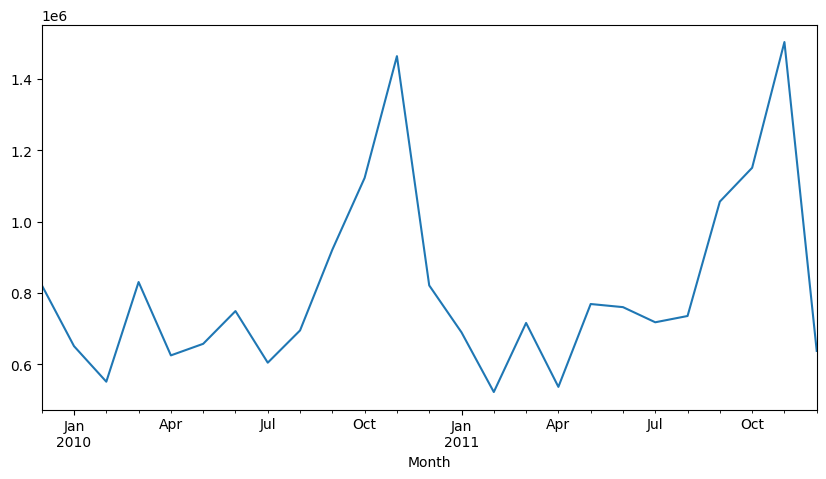

In [25]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(figsize=(10,5))

<p style="color:red; font-size:20px">
    Here, most of the sales are up in October, and there is a down sell in February and April.<br>
It's like a seasonal business where the sales go up from August up to October, then decrease slightly and go down again up to February.<br>
    Its a retail gift shop which sales go up on pre-Christmas Eve(Oct/nov) and go down on post-holiday (Feb) and in april possibly there is no event for retail.
</p>

    


In [26]:
df['Country'].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Denmark', 'Netherlands', 'Poland',
       'Channel Islands', 'Spain', 'Cyprus', 'Greece', 'Norway',
       'Austria', 'Sweden', 'United Arab Emirates', 'Finland', 'Italy',
       'Switzerland', 'Japan', 'Unspecified', 'Nigeria', 'Malta',
       'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore', 'Thailand',
       'Israel', 'Lithuania', 'West Indies', 'Lebanon', 'Korea', 'Brazil',
       'Canada', 'Iceland', 'Saudi Arabia', 'Czech Republic',
       'European Community'], dtype=object)

In [27]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    1.725152e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64

### 1.725152e+07 Its the format used by python for large values althogh it can be converted into normal values.

In [28]:
pd.options.display.float_format = '{:,.2f}'.format
country_sales.head(10)

Country
United Kingdom   17,251,519.98
EIRE                658,767.31
Netherlands         554,038.09
Germany             425,019.71
France              350,456.09
Australia           169,283.46
Spain               108,332.49
Switzerland         100,685.59
Sweden               91,869.82
Denmark              68,580.69
Name: TotalPrice, dtype: float64

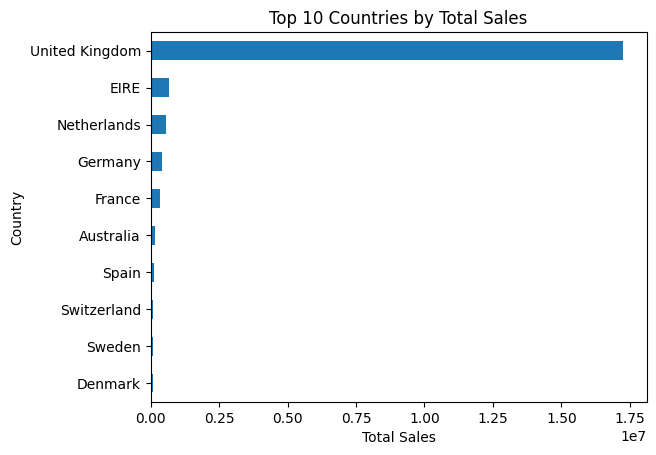

In [29]:
import matplotlib.pyplot as plt

# Get top 10 countries
top10 = country_sales.head(10)

plt.figure()
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.show()

<p style="color:red;font-size:20px">
    As its obvious that uk has most sales among others there is good market of it wheereas in other country there is a huge difference in sales which means Business is highly dependent on one market, Risk concentration exists, and there is a chance of expansion in other countries.
    
</p>


In [30]:
df['Description'] = df['Description'].str.strip()
df['Description'] = df['Description'].str.upper()

# strip()=Removes extra spaces from the beginning and end of text.
# upper()=convert all letters into uppercase Because groupby is case-sensitive.

In [31]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

top_products.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106250
WHITE HANGING HEART T-LIGHT HOLDER     94663
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80090
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77705
BROCADE RING PURSE                     70379
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48597
Name: Quantity, dtype: int64

###  top_products gives the high selling products which include Different gift products, small designs  and cakes.

In [32]:
top_revenue_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)
top_revenue_products.head(10)

Description
MANUAL                               339,241.29
REGENCY CAKESTAND 3 TIER             330,590.32
DOTCOM POSTAGE                       309,854.11
WHITE HANGING HEART T-LIGHT HOLDER   260,990.22
PAPER CRAFT , LITTLE BIRDIE          168,469.60
PARTY BUNTING                        148,318.28
JUMBO BAG RED RETROSPOT              148,073.47
ASSORTED COLOUR BIRD ORNAMENT        129,324.49
POSTAGE                              125,682.42
PAPER CHAIN KIT 50'S CHRISTMAS       117,760.29
Name: TotalPrice, dtype: float64

### top_revenue_products gives the prodct which generate more reveneu so these products need to be produce more to increase reveneu.

In [33]:
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)

top_customers.head(10)

Customer ID
18,102.00   580,987.04
14,646.00   528,602.52
14,156.00   313,437.62
14,911.00   291,420.81
17,450.00   244,784.25
13,694.00   195,640.69
17,511.00   172,132.87
16,446.00   168,472.50
16,684.00   147,142.77
12,415.00   144,458.37
Name: TotalPrice, dtype: float64

### top_customers gives the top customers of the company who uplift the revence and market flow of the company.

In [34]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106250
WHITE HANGING HEART T-LIGHT HOLDER     94663
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80090
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77705
BROCADE RING PURSE                     70379
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48597
Name: Quantity, dtype: int64

In [35]:
aov = df.groupby('Invoice')['TotalPrice'].sum().mean()
aov

np.float64(484.40942011777884)

### The average order value across transactions is £484.40942011777884.

### These negative values can distort the mean and histogram for visualization so they need to be removed temporarily for sale performance analysis.

In [36]:
order_totals_clean = df.groupby('Invoice')['TotalPrice'].sum()
order_totals_clean.describe()

count    41,943.00
mean        484.41
std       1,506.98
min     -53,594.36
25%         132.04
50%         290.70
75%         476.75
max     168,469.60
Name: TotalPrice, dtype: float64

In [37]:
order_totals_clean = order_totals_clean[order_totals_clean > 0]

In [38]:
order_totals_clean[order_totals_clean < 0]

Series([], Name: TotalPrice, dtype: float64)

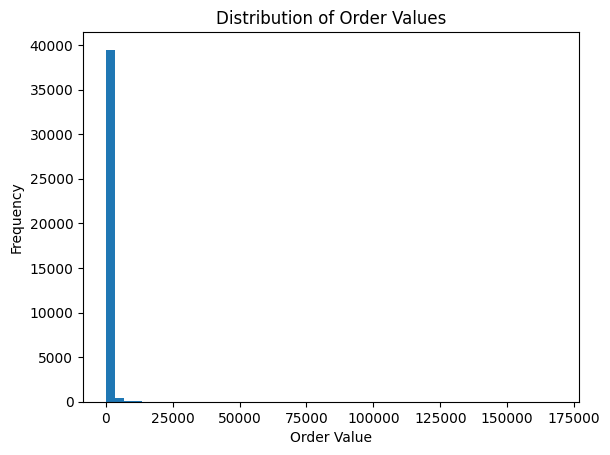

In [39]:
import matplotlib.pyplot as plt

plt.figure()
order_totals_clean.plot(kind='hist', bins=50)
plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

<p style="color:blue;font-size:20px;">
It is a compressed histogram because<br>
</p>
<p style="color:orange;font-size:20px;">
  Most values are between £0–£1000<br>
  But max value is £168,000<br>
  And min is -£53,000<br>
That huge range stretches the x-axis.<br>
This is called long-tail distribution.<br>
    so we need to remove the outliers temporarily for proper visualization
</p>


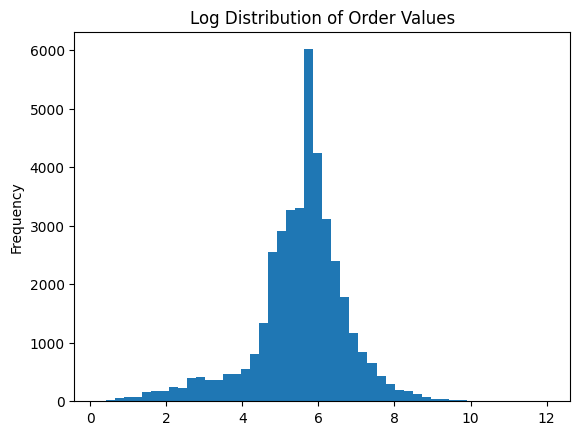

In [40]:
# Using Log Transformation

import numpy as np

plt.figure()
np.log1p(order_totals_clean[order_totals_clean > 0]).plot(kind='hist', bins=50)
plt.title("Log Distribution of Order Values")
plt.show()

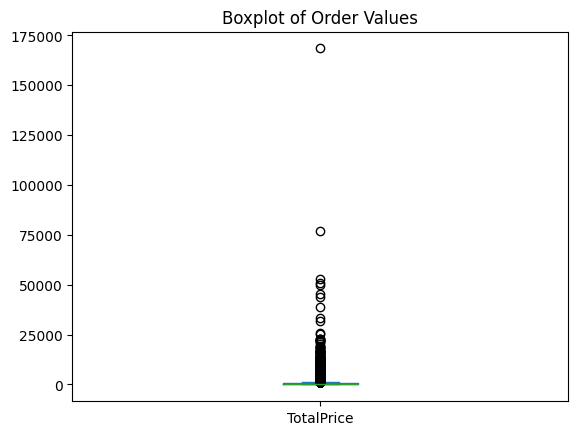

In [41]:
plt.figure()
order_totals_clean.plot(kind='box')
plt.title("Boxplot of Order Values")
plt.show()

In [42]:
top_10_percent = order_totals_clean.quantile(0.90)

In [43]:
order_totals_clean[order_totals_clean > top_10_percent].sum() / order_totals_clean.sum()

np.float64(0.47825665530428996)

### This selects only the top 10% largest orders and then calculate Percentage of revenue generated by the top 10% of orders. which gives 49% here, which means the company is heavily dependent on high buyers.

<p style="color:red;font-size:30px">RFM Features</p> 

In [44]:
import datetime as dt

reference_date = df['InvoiceDate'].max()

recency = df.groupby('Customer ID')['InvoiceDate'].max()
recency = (reference_date - recency).dt.days


In [45]:
frequency = df.groupby('Customer ID')['Invoice'].nunique()


In [46]:
monetary = df.groupby('Customer ID')['TotalPrice'].sum()


### Recency tells you the current health.<br>  Frequency tells you habit strength. <br>Monetary tells you the customer value.

In [47]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})


In [48]:
rfm

,Recency,Frequency,Monetary
Customer ID,,,
"12,346.00",325,12,"77,556.46"
"12,347.00",1,8,"4,921.53"
"12,348.00",74,5,"2,019.40"
"12,349.00",18,4,"4,428.69"
"12,350.00",309,1,334.40
...,...,...,...
"18,283.00",3,22,"2,664.90"
"18,284.00",431,1,461.68
"18,285.00",660,1,427.00


In [49]:
rfm.describe()

,Recency,Frequency,Monetary
count,"5,881.00","5,881.00","5,881.00"
mean,200.46,6.29,"2,954.40"
std,209.47,13.01,"14,437.32"
min,0.00,1.00,0.00
25%,25.00,1.00,341.90
50%,95.00,3.00,865.60
75%,379.00,7.00,"2,247.72"
max,738.00,398.00,"580,987.04"


In [50]:
high_m = rfm[rfm['Monetary'] > rfm['Monetary'].quantile(0.75)]
high_f = rfm[rfm['Frequency'] > rfm['Frequency'].quantile(0.75)]
recent_customers = rfm[rfm['Recency'] < rfm['Recency'].quantile(0.25)]
# it gives top 25% spenders with most recent buyers so we called them vip users.

In [51]:
vip = rfm[
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)) &
    (rfm['Frequency'] > rfm['Frequency'].quantile(0.75)) &
    (rfm['Recency'] < rfm['Recency'].quantile(0.25))
]

vip.head()


,Recency,Frequency,Monetary
Customer ID,,,
"12,347.00",1,8,"4,921.53"
"12,362.00",2,11,"5,356.23"
"12,380.00",21,11,"9,676.30"
"12,388.00",15,8,"3,901.11"
"12,395.00",18,15,"4,721.17"


In [52]:
loyal = rfm[
    (rfm['Frequency'] > rfm['Frequency'].quantile(0.75)) &
    (rfm['Recency'] < rfm['Recency'].quantile(0.25))
]
loyal

,Recency,Frequency,Monetary
Customer ID,,,
"12,347.00",1,8,"4,921.53"
"12,362.00",2,11,"5,356.23"
"12,380.00",21,11,"9,676.30"
"12,388.00",15,8,"3,901.11"
"12,395.00",18,15,"4,721.17"
...,...,...,...
"18,230.00",8,9,"4,291.06"
"18,241.00",9,21,"2,986.99"
"18,245.00",6,20,"6,324.98"


In [53]:
at_risk = rfm[
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)) &
    (rfm['Recency'] > rfm['Recency'].quantile(0.75))
]
at_risk

,Recency,Frequency,Monetary
Customer ID,,,
"12,469.00",522,2,"3,070.54"
"12,482.00",575,29,"23,691.40"
"12,511.00",428,1,"3,084.02"
"12,671.00",605,1,"2,622.48"
"12,737.00",498,2,"3,710.50"
...,...,...,...
"17,448.00",496,46,"14,523.67"
"17,465.00",425,7,"2,542.79"
"17,876.00",399,3,"3,424.02"


In [54]:
new_cust = rfm[
    (rfm['Recency'] < rfm['Recency'].quantile(0.25)) &
    (rfm['Frequency'] <= rfm['Frequency'].quantile(0.25))
]
new_cust

,Recency,Frequency,Monetary
Customer ID,,,
"12,367.00",3,1,168.90
"12,442.00",2,1,172.06
"12,478.00",3,1,680.99
"12,479.00",10,1,527.20
"12,558.00",7,1,269.96
...,...,...,...
"17,942.00",7,1,77.50
"17,985.00",21,1,631.35
"18,015.00",3,1,120.03


In [55]:
big_spenders = rfm[
    (rfm['Monetary'] > rfm['Monetary'].quantile(0.75)) &
    (rfm['Frequency'] <= rfm['Frequency'].quantile(0.75))
]
big_spenders

,Recency,Frequency,Monetary
Customer ID,,,
"12,349.00",18,4,"4,428.69"
"12,356.00",22,6,"6,371.73"
"12,357.00",32,3,"18,287.66"
"12,358.00",1,5,"3,887.07"
"12,370.00",50,7,"4,316.56"
...,...,...,...
"18,188.00",14,6,"3,280.59"
"18,194.00",81,6,"4,162.04"
"18,210.00",1,7,"2,768.83"


In [56]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [57]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [58]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [59]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [60]:
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_Score
Customer ID,,,,,,,,
"12,346.00",325,12,"77,556.46",2,5,5,255,255
"12,347.00",1,8,"4,921.53",5,4,5,545,545
"12,348.00",74,5,"2,019.40",3,4,4,344,344
"12,349.00",18,4,"4,428.69",5,3,5,535,535
"12,350.00",309,1,334.40,2,1,2,212,212
...,...,...,...,...,...,...,...,...
"18,283.00",3,22,"2,664.90",5,5,4,554,554
"18,284.00",431,1,461.68,1,2,2,122,122
"18,285.00",660,1,427.00,1,2,2,122,122


In [61]:
def segment_customer(row):
    
    if row['RFM_Score'] == '555':
        return 'Champions'
    
    elif row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Loyal Customers'
    
    elif row['F_score'] == 5:
        return 'Frequent Buyers'
    
    elif row['R_score'] <= 2 and row['F_score'] >= 4:
        return 'At Risk'
    
    elif row['R_score'] == 5 and row['F_score'] == 1:
        return 'New Customers'
    
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [62]:
rfm['Segment'].value_counts()

Segment
Others             3793
Loyal Customers    1013
Champions           469
At Risk             283
Frequent Buyers     268
New Customers        55
Name: count, dtype: int64

In [63]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
print(segment_revenue)

Segment
Champions         8,145,262.81
Loyal Customers   3,879,067.33
Others            3,217,341.93
Frequent Buyers   1,594,983.30
At Risk             518,722.57
New Customers        19,426.32
Name: Monetary, dtype: float64


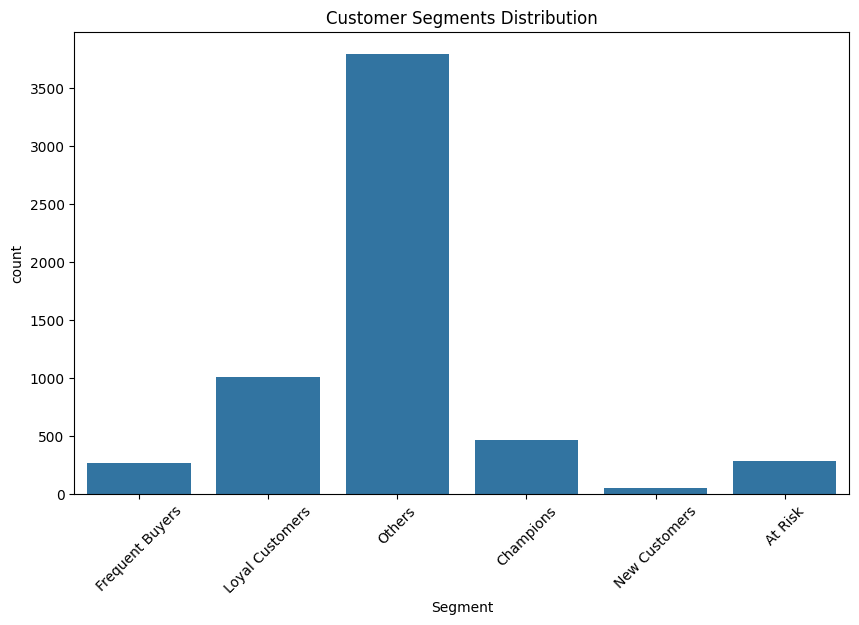

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.title("Customer Segments Distribution")
plt.show()

# The majority of customers fall into the Others category, while a smaller but highly valuable segment belongs to Champions and Loyal Customers, which generate a significant portion of revenue.

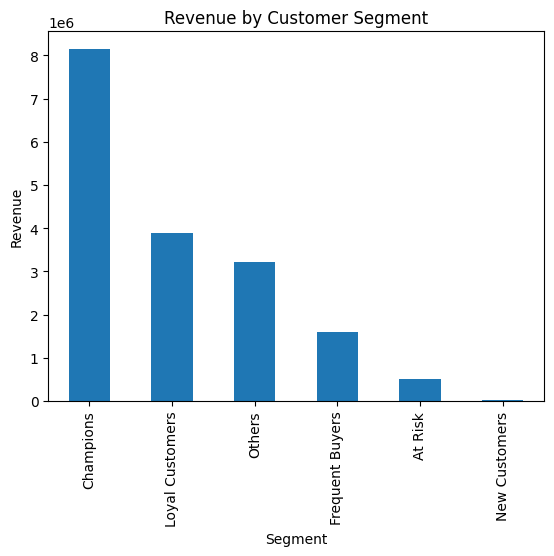

In [65]:
segment_revenue.plot(kind='bar')

plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")
plt.show()

# Champion customers generate the highest revenue contribution despite representing a smaller portion of total customers.

In [66]:
top_customers = rfm.sort_values(by="Monetary", ascending=False).head(10)

top_customers

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_Score,Segment
Customer ID,,,,,,,,,
"18,102.00",0,145,"580,987.04",5,5,5,555,555,Champions
"14,646.00",1,152,"528,602.52",5,5,5,555,555,Champions
"14,156.00",9,156,"313,437.62",5,5,5,555,555,Champions
"14,911.00",0,398,"291,420.81",5,5,5,555,555,Champions
"17,450.00",7,51,"244,784.25",5,5,5,555,555,Champions
"13,694.00",3,143,"195,640.69",5,5,5,555,555,Champions
"17,511.00",2,60,"172,132.87",5,5,5,555,555,Champions
"16,446.00",0,2,"168,472.50",5,2,5,525,525,Others
"16,684.00",3,55,"147,142.77",5,5,5,555,555,Champions


# A small number of customers account for extremely high spending, indicating the presence of high-value VIP buyers.

In [67]:
rfm.to_csv("../data/rfm_segments.csv", index=False)